In [1]:
!pip install langid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 78.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941216 sha256=86a2a3fcc62582b828bab05d50dd5a7a1df195ce075a236ea5d64a676eee5f89
  Stored in directory: /root/.cache/pip/wheels/50/d7/8b/f20e951da531c61b96b87311b48dd1cc6fedaf1e37c581aaee
Successfully built langid


In [2]:
from sklearn.cluster import k_means
from sentence_transformers import SentenceTransformer
from sentence_transformers import util
import numpy as np
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pickle
import random
import langid
import pickle

## Choose examples for the prompt

In [3]:
xsum = load_dataset("EdinburghNLP/xsum", revision="refs/convert/parquet")

default/train/0000.parquet: reconstructing file:   0%|          |  0.00B /  300MB            

default/train/0000.parquet: downloading bytes:           |  0.00B            

default/validation/0000.parquet: reconstructing file:   0%|          |  0.00B / 16.4MB            

default/validation/0000.parquet: downloading bytes:           |  0.00B            

default/test/0000.parquet: reconstructing file:   0%|          |  0.00B / 16.7MB            

default/test/0000.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [31]:
#xsum["validation"]["document"][0]

In [5]:
# use examples after example 100 (first 100 are the judge test instances)
valdocs = xsum["validation"]["document"][100:]
# use examples after index 200 (first 200 are the judge test instances)
testdocs = xsum["test"]["document"][200:]

In [6]:
# define a function that checks if the document is in english
def is_english(text):
  lang, score = langid.classify(text.replace("\n", " ")[:500])
  return lang == "en"

**Change to false for test set calculation:**

In [7]:
use_validation = True

In [8]:
# create a list of all english docs
docs = valdocs if use_validation else testdocs

en_docs = [doc for doc in docs if is_english(doc)]

In [9]:
# load pre-trained model for embeddings
model = SentenceTransformer("all-mpnet-base-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
# encode documents into embeddings
embeddings = model.encode(en_docs)
#print(embeddings.shape)

#Examples for Cluster-based Similarity

## Cluster embeddings with K-means++ initialization

In [11]:
centroids, labels, inertia = k_means(embeddings, n_clusters=3, init='k-means++', random_state=42)

In [12]:
# Centroids found at the last iteration of k-means
#print(centroids.shape)
#print(labels.shape)

## Use PCA to reduce results to 2D for visualization


In [13]:
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)
centers_2d = pca.transform(centroids)
#print(embeddings_2d.shape)

Text(0, 0.5, 'Principal Component 2')

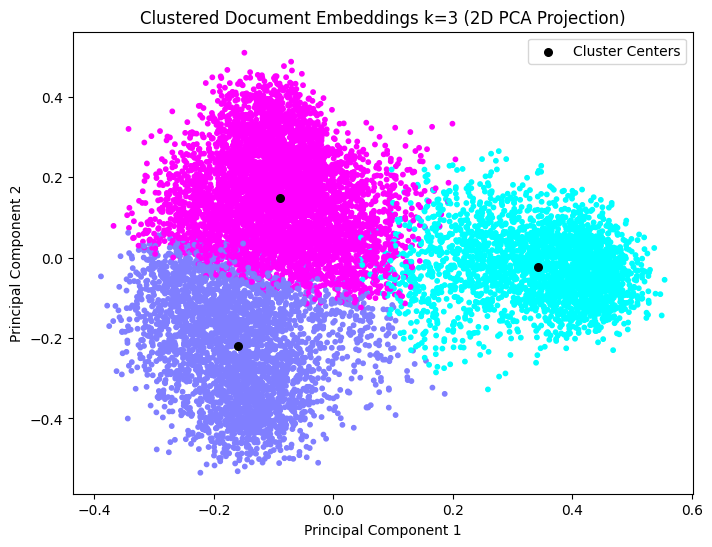

In [14]:
# plot of the clustered document embeddings and the cluster centers
plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            c=labels, s=10, cmap='cool')
# centers
plt.scatter(centers_2d[:, 0], centers_2d[:, 1],
            c='black', marker='o', s=30, label='Cluster Centers')

plt.legend()
plt.title('Clustered Document Embeddings k=3 (2D PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
#plt.show()


## Get examples close to judge test instances

In [15]:
# first 100 validation set examples or first 200 test set examples as judge test instances
data = xsum["validation"]["document"][:100] if use_validation else xsum["test"]["document"][:200]

In [16]:
# turn each document (input) of the instances into an embedding vector and create a list of embeddings
embeddings_inputs = []
for inst in data:
  emb = model.encode(inst)
  embeddings_inputs.append(emb)
#print(embeddings_inputs[0].shape)

In [17]:
# transform into 2D with PCA
embeddings_inputs_2d = pca.transform(embeddings_inputs)
#print(embeddings_inputs_2d.shape)

Text(0, 0.5, 'Principal Component 2')

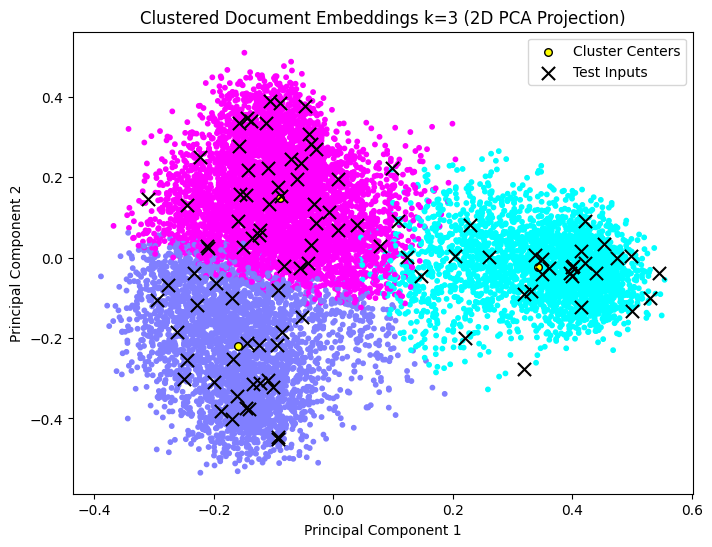

In [18]:
# plot of the clustered document embeddings, the cluster centers and the test inputs
plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            c=labels, s=10, cmap='cool')

# centers
plt.scatter(centers_2d[:, 0], centers_2d[:, 1],
            c='yellow', marker='o',edgecolor='black',s=30, label='Cluster Centers')

# inputs
plt.scatter(embeddings_inputs_2d[:, 0], embeddings_inputs_2d[:, 1],
            c='black', marker='x', s=90, label='Test Inputs')

plt.legend()
plt.title('Clustered Document Embeddings k=3 (2D PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
#plt.show()

For every test input embedding we have to find the 3 closest embeddings by cluster

In [19]:
def closest_docs_by_cluster(embeddings, input_embeddings, labels, n_clusters):
    input_embeddings = np.array(input_embeddings)
    results = []

    for inp_emb in input_embeddings:
        cluster_indices = []

        for c in range(n_clusters):
            # mask docs in this cluster
            cluster_mask = (labels == c)
            cluster_embs = embeddings[cluster_mask]
            cluster_ids = np.where(cluster_mask)[0]

            # compute distances within this cluster
            distances = np.linalg.norm(cluster_embs - inp_emb, axis=1)

            # pick closest document in this cluster
            closest_idx = cluster_ids[np.argmin(distances)]
            cluster_indices.append(closest_idx)

        results.append(cluster_indices)

    return results


In [20]:
closest_indices_val = closest_docs_by_cluster(
    embeddings,
    embeddings_inputs,
    labels,
    n_clusters=3
)
#print(len(closest_indices) == 100)

Save all three examples for each input

In [21]:
# use the indices to get the embeddings and save them in a list
examples = []
for sublist in closest_indices_val:
  for i in sublist:
    examples.append(embeddings[i])
# turn into numpy array
examples = np.array(examples)
#print(examples[0].shape)

In [22]:
# 2D PCA projection of the example embeddings
examples_2d = pca.transform(examples)
#print(examples_2d.shape)

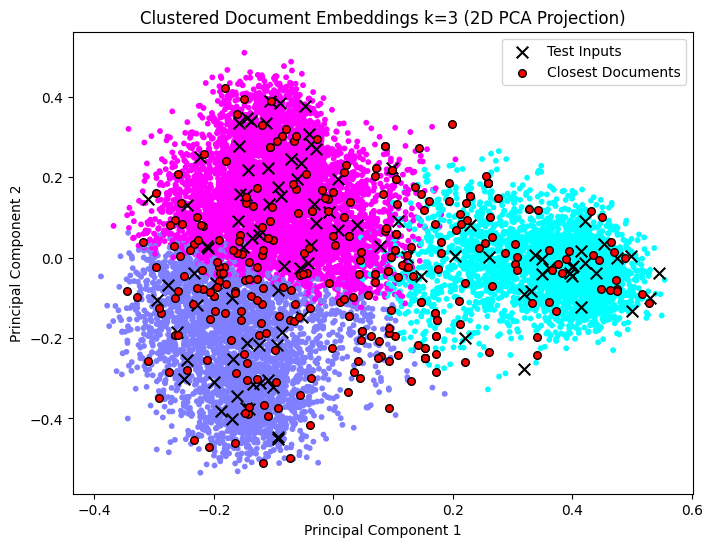

In [23]:
# plot of the clustered document embeddings, the test inputs and their closest documents
plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
             c=labels, s=10, cmap='cool')

# inputs
plt.scatter(embeddings_inputs_2d[:, 0], embeddings_inputs_2d[:, 1],
            c='black', marker='x', s=70, label='Test Inputs')

# closest examples
plt.scatter(examples_2d[:, 0], examples_2d[:, 1],
            c='red', marker='o', edgecolor='black', s=30, label='Closest Documents')

plt.legend()
plt.title('Clustered Document Embeddings k=3 (2D PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [24]:
if use_validation:
  with open("closest_indices_val_cluster.pkl", "wb") as f:
    pickle.dump(closest_indices_val, f)
else:
  with open("closest_indices_test_cluster.pkl", "wb") as f:
    pickle.dump(closest_indices_val, f)

# Examples based on Similarity

In [25]:
def closest_docs_by_similarity(embeddings, input_embeddings, n_clusters):
    # Convert to numpy array
    input_embeddings = np.array(input_embeddings)
    # Compute pairwise distances: shape (M, N)
    distances = np.linalg.norm(input_embeddings[:, None, :] - embeddings[None, :, :], axis=2)
    # Sort distances and get the indices of the k smallest
    closest_indices = np.argsort(distances, axis=1)[:, :n_clusters]
    return closest_indices

In [26]:
closest_indices_sim = closest_docs_by_similarity(
    embeddings,
    embeddings_inputs,
    n_clusters=3
    )
#print(len(closest_indices_sim) == 100)

Save all three examples for each input

In [27]:
# use the indices to get the embeddings and save them in a list
examples_sim = []
for sublist in closest_indices_sim:
  for i in sublist:
    examples_sim.append(embeddings[i])
# turn into numpy array
examples_sim = np.array(examples_sim)
#print(examples_sim[0].shape)

In [28]:
# 2D PCA projection of the example embeddings
examples_2d_sim = pca.transform(examples_sim)
#print(examples_2d.shape)

Text(0, 0.5, 'Principal Component 2')

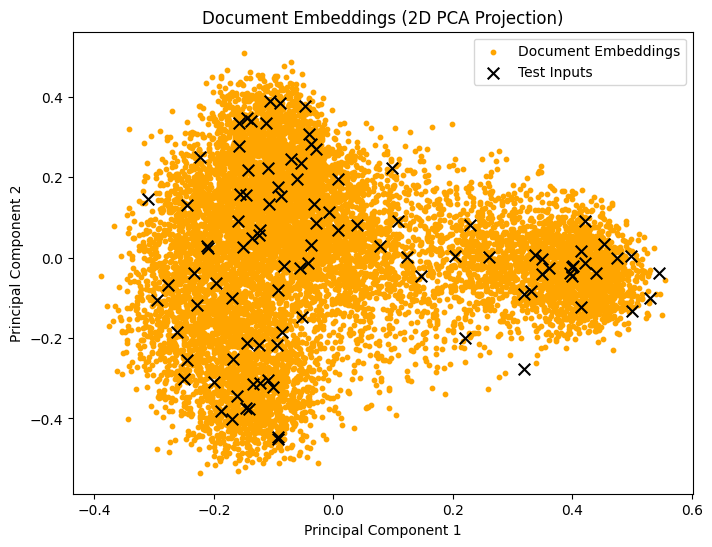

In [29]:
# plot of the document embeddings, the test inputs and their closest documents
plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            s=10, c='orange', label='Document Embeddings')

# inputs
plt.scatter(embeddings_inputs_2d[:, 0], embeddings_inputs_2d[:, 1],
            c='black', marker='x', s=70, label='Test Inputs')

# closest examples
#plt.scatter(examples_2d_sim[:, 0], examples_2d_sim[:, 1],
            #c='red', marker='o', edgecolor='black', s=30, label='Closest Documents')

plt.legend()
plt.title('Document Embeddings (2D PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

In [30]:
if use_validation:
  with open("closest_indices_val_sim.pkl", "wb") as f:
    pickle.dump(closest_indices_sim, f)
else:
  with open("closest_indices_test_sim.pkl", "wb") as f:
    pickle.dump(closest_indices_sim, f)